In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [12]:
df = pd.read_csv(r"C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\Iris.csv")
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [13]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)  # keep all components first
X_pca = pca.fit_transform(X_scaled)

In [16]:
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")


Explained Variance Ratio:
PC1: 0.7471
PC2: 0.1844
PC3: 0.0468
PC4: 0.0176
PC5: 0.0041


In [17]:
pca_optimal = PCA(n_components=2)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

In [18]:
pca_df = pd.DataFrame(data=X_pca_optimal, columns=["PC1", "PC2"])
pca_df["Target"] = y
print("\nTransformed Dataset:")
print(pca_df.head())


Transformed Dataset:
        PC1       PC2       Target
0 -2.816339  0.506051  Iris-setosa
1 -2.645527 -0.651799  Iris-setosa
2 -2.879481 -0.321036  Iris-setosa
3 -2.810934 -0.577363  Iris-setosa
4 -2.879884  0.670468  Iris-setosa


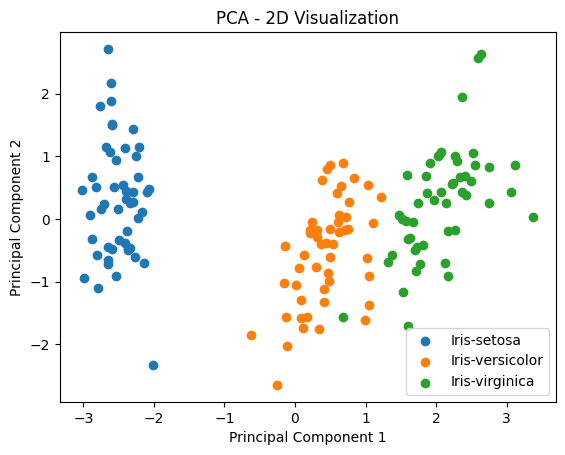

In [19]:
plt.figure()
for label in pca_df["Target"].unique():
    subset = pca_df[pca_df["Target"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")
plt.legend()
plt.show()